# Exploratory Data Analysis (EDA) - CSIRO Image2Biomass

**Objective:** This notebook performs an exploratory data analysis of the [CSIRO - Image2Biomass Prediction](https://www.kaggle.com/competitions/csiro-image2biomass-prediction) competition data.

The purpose is to understand the structure and characteristics of the training and test data. This includes:
*   Loading the data and verifying its structure.
*   Identifying the data types of each column.
*   Analyzing the presence of missing data.
*   Studying the distribution of numerical variables.
*   Examining the characteristics of categorical variables.

This analysis will serve as a basis for preprocessing and building machine learning models.

## 1. Environment Setup

First, we import the necessary libraries for the analysis.

In [18]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Data Loading

Logic is implemented to load data from either the Kaggle environment (`/kaggle/input/csiro-biomass/`) or a local folder (`data/`). This ensures that the notebook can be run in both environments without modifications.

In [19]:
def get_data_dir():
    """Returns the data directory based on the environment (Kaggle or local)."""
    if Path("/kaggle/input/csiro-biomass").exists():
        return Path("/kaggle/input/csiro-biomass")
    else:
        return Path("data")

DATA_DIR = get_data_dir()
print(f"Data directory: {DATA_DIR}")

try:
    train_df = pd.read_csv(DATA_DIR / 'train.csv')
    test_df = pd.read_csv(DATA_DIR / 'test.csv')
    sample_submission_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')
    print("CSV files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Make sure the data is in the 'data' folder if you are running locally.")

Data directory: data
CSV files loaded successfully.


## 3. Data Overview

We explore the dimensions, columns, and data types of each DataFrame.

In [20]:
print("--- Training DataFrame Info ---")
train_df.info()

print("\n--- First rows of the Training DataFrame ---")
display(train_df.head())

--- Training DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_id      1785 non-null   object 
 1   image_path     1785 non-null   object 
 2   Sampling_Date  1785 non-null   object 
 3   State          1785 non-null   object 
 4   Species        1785 non-null   object 
 5   Pre_GSHH_NDVI  1785 non-null   float64
 6   Height_Ave_cm  1785 non-null   float64
 7   target_name    1785 non-null   object 
 8   target         1785 non-null   float64
dtypes: float64(3), object(6)
memory usage: 125.6+ KB

--- First rows of the Training DataFrame ---


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


In [21]:
print("--- Test DataFrame Info ---")
test_df.info()

print("\n--- First rows of the Test DataFrame ---")
display(test_df.head())

--- Test DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sample_id    5 non-null      object
 1   image_path   5 non-null      object
 2   target_name  5 non-null      object
dtypes: object(3)
memory usage: 252.0+ bytes

--- First rows of the Test DataFrame ---


,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


## 4. Missing Data Analysis

In [22]:
print("--- Missing Data in Training Set ---")
print(train_df.isnull().sum())

print("\n--- Missing Data in Test Set ---")
print(test_df.isnull().sum())

--- Missing Data in Training Set ---
sample_id        0
image_path       0
Sampling_Date    0
State            0
Species          0
Pre_GSHH_NDVI    0
Height_Ave_cm    0
target_name      0
target           0
dtype: int64

--- Missing Data in Test Set ---
sample_id      0
image_path     0
target_name    0
dtype: int64


**Observation:**
*   The training DataFrame has no missing data.
*   The test DataFrame has no missing data in its columns.

## 5. Numerical Variables Analysis

We study the descriptive statistics and distribution of the numerical variables.

In [23]:
print("--- Descriptive Statistics (Training) ---")
display(train_df.describe())

--- Descriptive Statistics (Training) ---


,Pre_GSHH_NDVI,Height_Ave_cm,target
count,1785.000000,1785.000000,1785.000000
mean,0.657423,7.595985,24.782295
std,0.151972,10.273725,25.823738
min,0.160000,1.000000,0.000000
25%,0.560000,3.000000,4.818200
50%,0.690000,4.000000,18.200000
75%,0.770000,7.000000,35.940600
max,0.910000,70.000000,185.700000


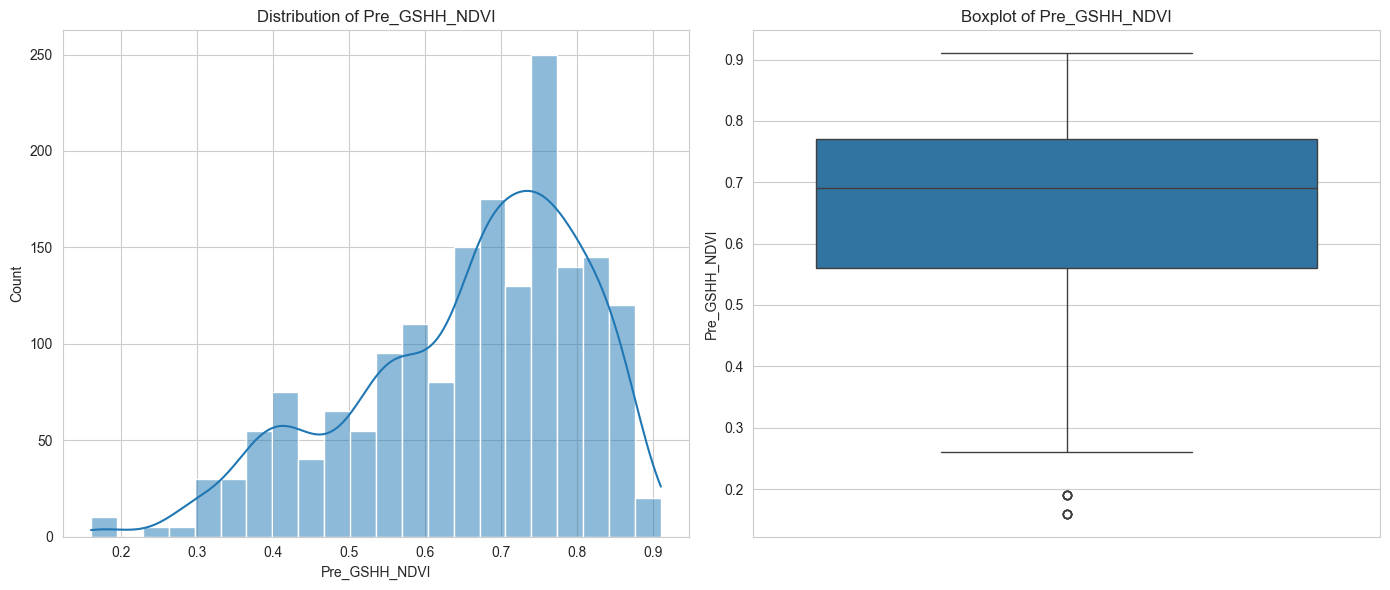

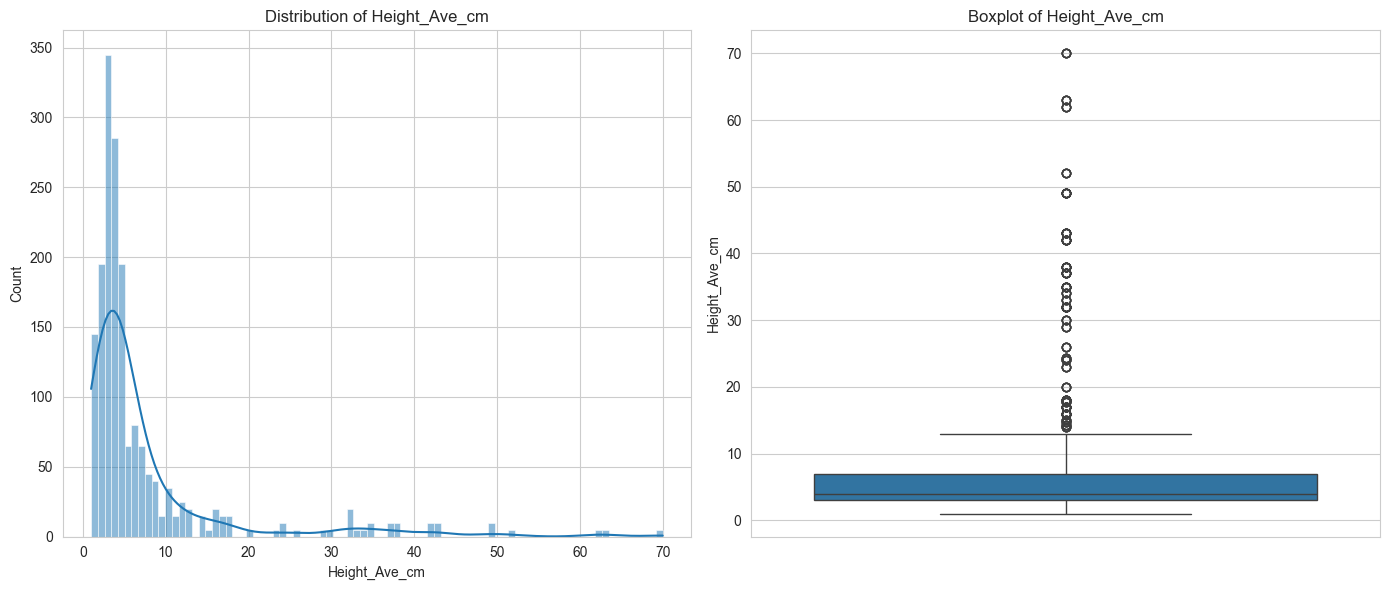

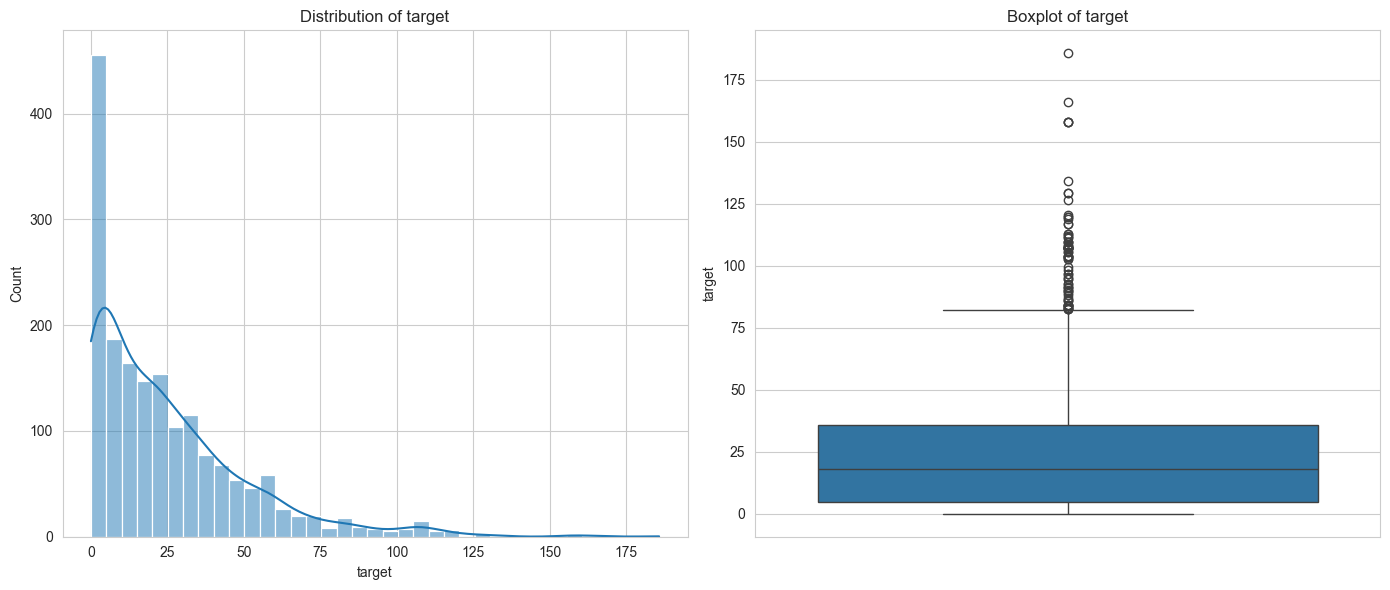

In [24]:
numerical_cols = ['Pre_GSHH_NDVI', 'Height_Ave_cm', 'target']

for col in numerical_cols:
    plt.figure(figsize=(14, 6))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=train_df[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

**Observations:**
*   `Pre_GSHH_NDVI`: The distribution appears bimodal, with peaks around 0.6 and 0.8.
*   `Height_Ave_cm`: The distribution is right-skewed, with most values concentrated at low heights and some high outliers.
*   `target`: The distribution is also heavily right-skewed, which is common in biomass measurements. A logarithmic transformation might be useful to normalize it during modeling.

### `target` Distribution by `target_name`

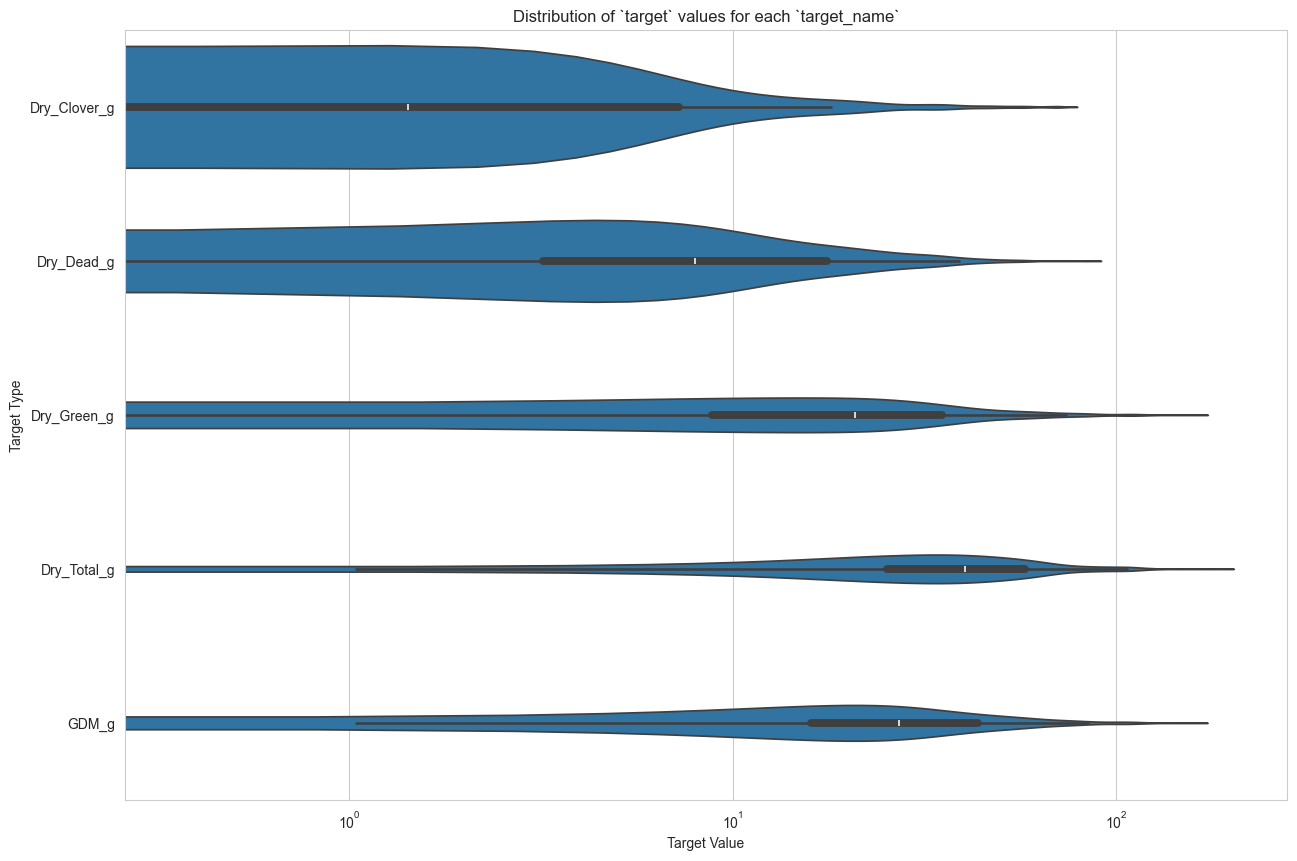

In [25]:
plt.figure(figsize=(15, 10))
sns.violinplot(data=train_df, x='target', y='target_name')
plt.title('Distribution of `target` values for each `target_name`')
plt.xlabel('Target Value')
plt.ylabel('Target Type')
plt.xscale('log') # Use log scale due to skewness
plt.show()

## 6. Categorical Variables Analysis

We analyze the `State`, `Species`, and `target_name` variables.

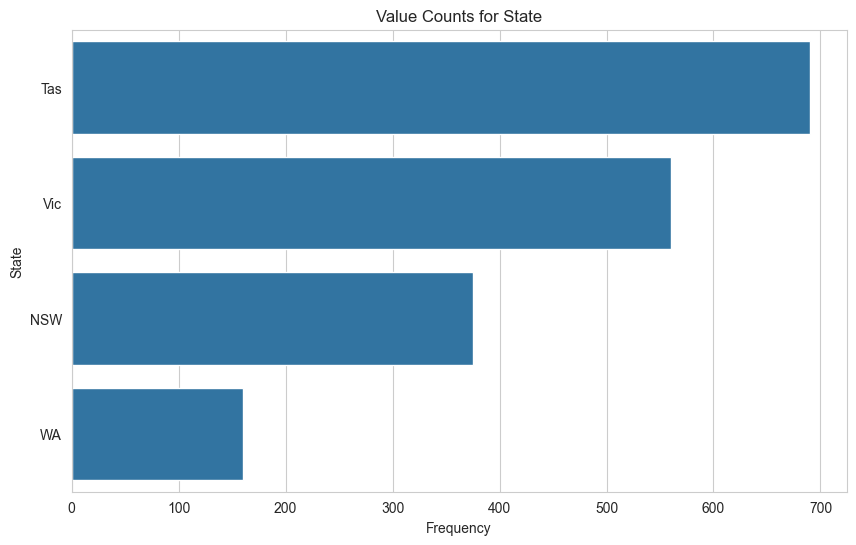

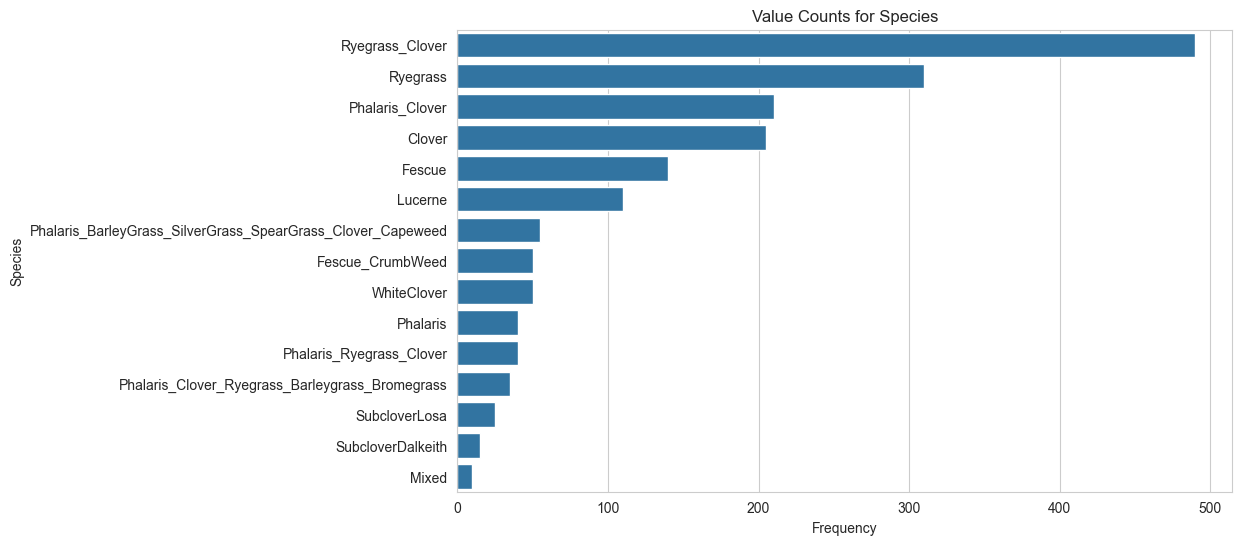

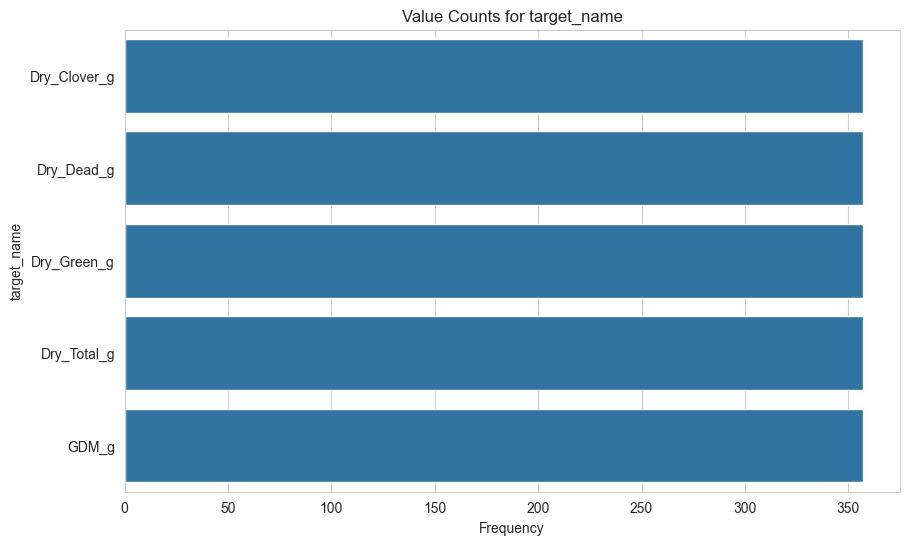

In [ ]:
categorical_cols = ['State', 'Species']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=train_df[col], order=train_df[col].value_counts().index)
    plt.title(f'Value Counts for {col}')
    plt.xlabel('Frequency')
    plt.ylabel(col)
    plt.show()

**Observations:**
*   `State`: Samples come mainly from `Vic` (Victoria) and `NSW` (New South Wales).
*   `Species`: The dominant species is `Ryegrass_Clover`.
*   `target_name`: As expected, all categories have the same number of samples, since each image has 5 biomass measurements.

These categorical variables (`State` and `Species`) are **nominal**, as they have no intrinsic order. They will need to be encoded (e.g., with One-Hot Encoding) to be used in most machine learning models.

## 7. Sampling Date Analysis (`Sampling_Date`)

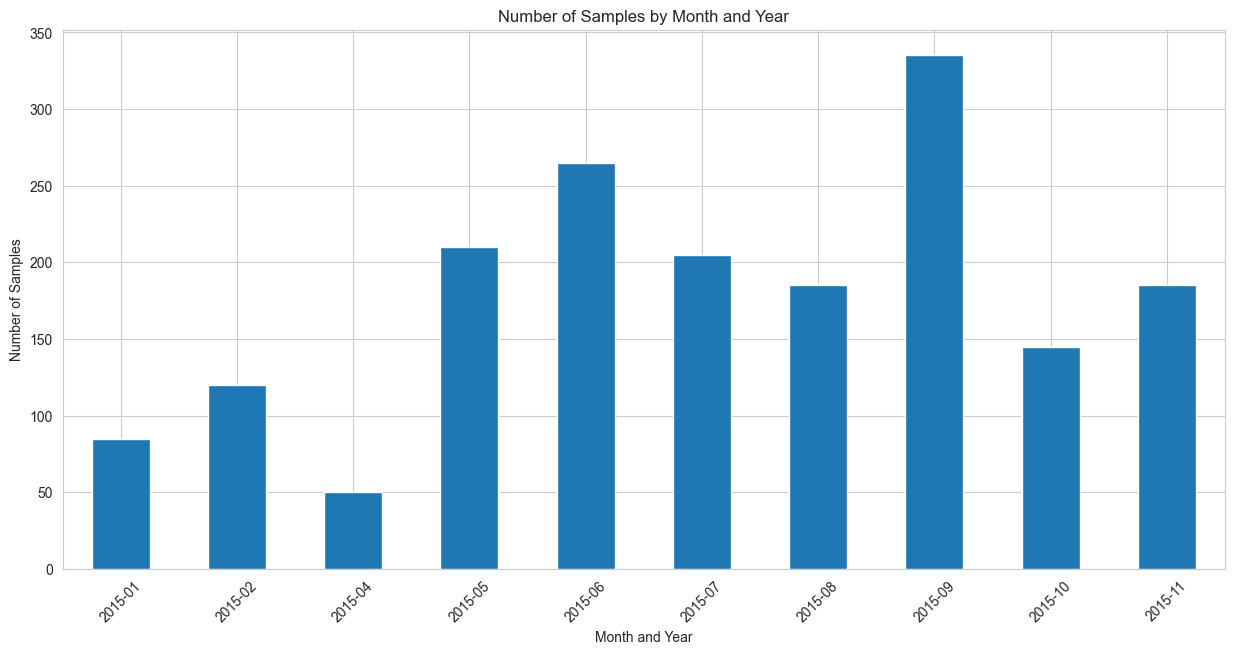

In [27]:
train_df['Sampling_Date'] = pd.to_datetime(train_df['Sampling_Date'])

plt.figure(figsize=(15, 7))
train_df['Sampling_Date'].dt.to_period('M').value_counts().sort_index().plot(kind='bar')
plt.title('Number of Samples by Month and Year')
plt.xlabel('Month and Year')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

**Observation:**
Most samples were taken between late 2015 and early 2017. Seasonality could be an important feature to consider in the model.

## EDA Conclusions

1.  **Data Structure:** The dataset is in long format, with one row per image-biomass type combination. For modeling, it will be necessary to pivot the table to have one row per image and one column per biomass type.
2.  **Missing Data:** No missing data was found in the training set.
3.  **Numerical Variables:** The `Height_Ave_cm` and `target` variables are heavily skewed. A transformation (like `log(x+1)`) could be applied to normalize them.
4.  **Categorical Variables:** `State` and `Species` are nominal variables and will require encoding for the model. The distribution of samples is not uniform across states and species.
5.  **Temporal Variable:** The sampling date (`Sampling_Date`) suggests potential seasonality that could be useful as a feature (e.g., by extracting the month or season).